# Jaguar Re-ID — ViT Improved v5

**Architecture** : identique a v4 (ViT + `relu`, `embed_dim=64`, 3 blocs, `AdamW(wd=1e-4)`). On isole l'effet de **Dropout**.

### Diagnostic v4 (point de depart)

| Metrique | Valeur | Commentaire |
|----------|--------|-------------|
| Val Acc | 72.30 % | Le modele apprend |
| Train Acc | 98.42 % | Memorisation tres elevee |
| Gap train/val | **26 pts** | Overfitting severe, pire qu'en v3 |
| Retrain train acc | 100.00 % | Memorisation parfaite |
| Kaggle pub / priv | 0.264 / 0.271 | +11 % / +16 % vs v3 (0.238 / 0.233) |

v4 a montre qu'AdamW ameliore la geometrie des embeddings **sans reduire** le gap. Le gap reste le probleme central.

### Tentative 1 (cassee) : Dropout(0.2) a 3 points "post-bloc"

Premiere tentative : `Dropout(0.2)` apres la sortie d'attention, apres les deux Dense du FFN, et apres l'embedding.

**Resultat : collapse total.** Toutes les LR a 9.5 % val (random). Retrain : **9.66 % train acc**.

**Explication** : Dropout apres les deux Dense(relu) du FFN zero 20 % de sorties deja clairsemees (ReLU zero les negatifs), juste avant le skip connection -> chemin residuel trop bruite.

### Tentative 2 (cassee aussi) : Dropout(0.1), 3 points, placement standard

Deux corrections : `0.2 -> 0.1`, et FFN dropout **entre** les deux Dense (placement standard ViT).

**Resultat : instabilite totale.** Le sweep a eu un run chanceux (`lr_5e-4 -> 64 %`), mais la **re-evaluation** avec un nouveau modele sur BEST_LR=5e-4 s'est effondree a **9.7 % train / 9.5 % val**. Retrain : **9.82 %**.

Le ViT naïf (petit, pas d'inductive bias, 1516 images) est **trop fragile** pour absorber du dropout sur le chemin des transformer blocks, meme a 0.1. L'entraînement devient non-deterministe : quelques seeds chanceux convergent, la plupart collapsent.

### Changement v5 final : Dropout(0.1) UNIQUEMENT sur l'embedding

Strategie minimale et sure :

- **Dropout retire** des blocs attention et FFN (residuels preserves).
- **Dropout(0.1) garde uniquement** sur la couche d'embedding (juste avant softmax).

**Justification** : la couche d'embedding est le seul endroit ou le dropout ne perturbe **aucun skip connection** ni aucune structure residuelle. Il agit comme une simple regularisation sur la tête de classification, proche d'un `DropConnect` sur le softmax.

**Effet attendu** :
- Le modele apprend de maniere stable (comme v4)
- Regularisation modeste -> gap train/val peut-etre legerement reduit
- Si effet insuffisant : v6 essaiera data augmentation (plus cours-friendly que dropout plus fort)

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1776584399.831722    1878 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776584400.390321    1878 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776584401.960972    1878 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1776584403.796328    1878 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
MODEL_NAME   = 'vit_improved_v5'
AUGMENTATION = 'none'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

# ViT architecture hyperparameters (identique a v3/v4)
EMBED_DIM  = 64      # Patch embedding dimension
NUM_BLOCKS = 3       # Number of transformer blocks
PATCH_SIZE = 16      # Patch size (16x16 pixels)
ACTIVATION = 'relu'  # tanh → relu (fix de v2)

# Regularisation v4 (heritee) : AdamW + weight decay
WEIGHT_DECAY = 1e-4  # regularisation naturelle decouplee du LR

# Regularisation v5 : Dropout UNIQUEMENT sur l'embedding
# Note : 2 tentatives precedentes cassees
#   - Dropout=0.2 a 3 points (attention + FFN + embedding) -> collapse total
#   - Dropout=0.1 a 3 points (placement FFN standard)      -> instabilite retrain
# Le ViT naïf du cours (petit, pas d'inductive bias) est trop fragile pour
# supporter du dropout sur le chemin residuel des transformer blocks.
# On garde le dropout uniquement sur la couche d'embedding, hors residuels.
DROPOUT_RATE = 0.1

# Retrain fix
# Historique des tentatives :
#   - MIN=60 (v4 default)  : OK pour v4 sans dropout
#   - MIN=150 (1er essai)  : avec dropout, retrain a atteint 99.4 % en 150 epochs
#                            -> embeddings hyper-sparses (ReLU + overfitting),
#                            similarites ecrasees vers 0 (20 % exactement a 0.0).
#                            Distribution cassee : mean=0.18, std=0.20.
#                            Comparaison ResNet v6 (Kaggle 0.630) : mean=0.62,
#                            std=0.12, distribution en cloche bien centree.
# Retour a MIN=60 : RETRAIN = max(4*BEST_EPOCH, 60). Avec BEST_EPOCH=16 et dropout,
# ca donne ~64 epochs, regime modere qui evite l'over-retrain.
RETRAIN_EPOCHS_MULTIPLIER = 4    # retrain = max(4 * BEST_EPOCH, RETRAIN_EPOCHS_MIN)
RETRAIN_EPOCHS_MIN        = 60   # revenu a la valeur v4 apres over-retrain a 150

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

W0000 00:00:1776584408.122537    1878 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776584408.324085    1878 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

Architecture **identique a v4** — seul l'ajout de Dropout change.

| Parametre | v4 | v5 | Pourquoi |
|-----------|----|----|----------|
| Architecture | ViT + relu | ViT + relu (idem) | On isole l'effet du dropout |
| Optimizer | `AdamW(wd=1e-4)` | `AdamW(wd=1e-4)` (idem) | On garde AdamW de v4 |
| Dropout | 0 | **0.1 sur l'embedding uniquement** | Regularisation minimale, sans perturber les residuels |
| Retrain epochs | `max(4*BEST_EPOCH, 60)` | `max(4*BEST_EPOCH, 60)` (idem) | Fix retrain de v3 |

### Placement du Dropout (final)

```
Attention : ...matmul(Masks, V) -> Add(skip)                 (PAS de dropout)
FFN       : LN -> Dense(relu) -> Dense(relu) -> Add(skip)    (PAS de dropout)
Embedding : Flatten -> Dense(relu, embedding) -> Dropout -> Dense(softmax)
```

Apres deux tentatives cassees (tentative 1 : 3 dropouts a 0.2 -> collapse ; tentative 2 : 3 dropouts a 0.1 -> instabilite), on revient a la strategie minimale : dropout uniquement sur l'embedding.

In [4]:
def positional_embedding(embedded_patches):
    """One-hot positional encoding (cours) : concat one-hot(position) to each patch."""
    embedded_patches_shape = tf.shape(embedded_patches)
    batchsize = embedded_patches_shape[0]
    sequence_length = embedded_patches_shape[1]
    indices = tf.range(sequence_length)
    one_hot_indices = tf.one_hot(indices, sequence_length)
    expanded_one_hot_indices = tf.expand_dims(one_hot_indices, axis=0)
    repeated_expanded_one_hot_indices = tf.repeat(expanded_one_hot_indices, [batchsize], axis=0)
    positional_embedded_patches = tf.concat([repeated_expanded_one_hot_indices, embedded_patches], axis=-1)
    return positional_embedded_patches


def build_model():
    input_tensor = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = input_tensor

    # Patch embedding
    x = layers.Conv2D(EMBED_DIM, (PATCH_SIZE, PATCH_SIZE), strides=(PATCH_SIZE, PATCH_SIZE),
                      activation='linear', use_bias=False, padding='valid')(x)
    sequence_length = x.shape[1] * x.shape[2]  # 14*14 = 196
    sqrt_sequence_length = np.sqrt(sequence_length)

    x = layers.Reshape((sequence_length, EMBED_DIM))(x)

    # Positional encoding : one-hot concat
    x = layers.Lambda(positional_embedding)(x)
    real_embedding_dim = sequence_length + EMBED_DIM  # 196 + 64 = 260

    # Transformer blocks (identique a v4, PAS de dropout dans les blocs)
    for _ in range(NUM_BLOCKS):
        # Self-attention
        old_x = x
        x = layers.LayerNormalization()(x)

        Q = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        K = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        V = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)

        Kt = layers.Lambda(lambda t: tf.transpose(t, [0, 2, 1]))(K)
        QKt = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]) / sqrt_sequence_length)([Q, Kt])
        Masks = layers.Softmax()(QKt)
        x = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]))([Masks, V])
        x = layers.Add()([x, old_x])

        # Feed-forward
        old_x = x
        x = layers.LayerNormalization()(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Add()([x, old_x])

    # Classification head — DROPOUT UNIQUEMENT ICI
    x = layers.Flatten()(x)
    x = layers.Dense(real_embedding_dim, activation=ACTIVATION, name='embedding')(x)
    x = layers.Dropout(DROPOUT_RATE)(x)                            # v5 : seul dropout, sur l'embedding
    output_tensor = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(input_tensor, output_tensor, name=MODEL_NAME)
    return model


model = build_model()
model.summary()

Model: "vit_improved_v5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │     49,152 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 196, 64)   │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 196, 260)  │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 260)  │        520 │ lambda[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 260, 196)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 196, 196)  │          0 │ dense[0][0],      │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 196, 196)  │          0 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 196, 260)  │          0 │ softmax[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 260)  │          0 │ lambda_3[0][0],   │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 260)  │     67,860 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 260)  │          0 │ dense_4[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 14,328,123 (54.66 MB)

 Trainable params: 14,328,123 (54.66 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter sweep

Meme sweep que v3/v4. Dropout peut decaler le BEST_LR (la regularisation absorbe une partie du bruit, le LR optimal peut etre un peu plus grand).

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 5e-4, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}, wd={WEIGHT_DECAY}, dropout={DROPOUT_RATE}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (vit_improved_v5, wd=0.0001, dropout=0.1) ===


I0000 00:00:1776584413.105998    4791 service.cc:153] XLA service 0x7fc0040466f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776584413.106047    4791 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776584413.194253    4791 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776584413.695453    4791 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776584413.768436    4791 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10666__.101
I0000 00:00:1776584413.866950    4791 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set inste

  lr_0.01: val_acc=0.0950 (best epoch=38)


I0000 00:00:1776584470.800457    4790 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_59783__.101
I0000 00:00:1776584474.509104    4790 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_59783__.101
I0000 00:00:1776584477.683581    4790 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_61127__.28
I0000 00:00:1776584478.661270    4793 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_61127__.28


  lr_0.001: val_acc=0.0950 (best epoch=99)


I0000 00:00:1776584531.036255    4792 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_153458__.101
I0000 00:00:1776584534.785029    4792 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_153458__.101
I0000 00:00:1776584537.974846    4791 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_154802__.28
I0000 00:00:1776584538.949328    4790 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_154802__.28


  lr_0.0005: val_acc=0.6755 (best epoch=16)


I0000 00:00:1776584554.944591    4792 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_184776__.101
I0000 00:00:1776584557.811818    4793 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_184776__.101
I0000 00:00:1776584560.995482    4793 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_186120__.28
I0000 00:00:1776584561.996406    4792 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_186120__.28


  lr_0.0001: val_acc=0.4195 (best epoch=28)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} → val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")
print(f"BEST_LR = {BEST_LR}, BEST_EPOCH = {BEST_EPOCH}")

,Config,Val Accuracy,Best Epoch
0,lr_0.0005,0.675462,16
1,lr_0.0001,0.419525,28
2,lr_0.001,0.094987,99
3,lr_0.01,0.094987,38



Best: lr_0.0005 → val_acc=0.6755
BEST_LR = 0.0005, BEST_EPOCH = 16


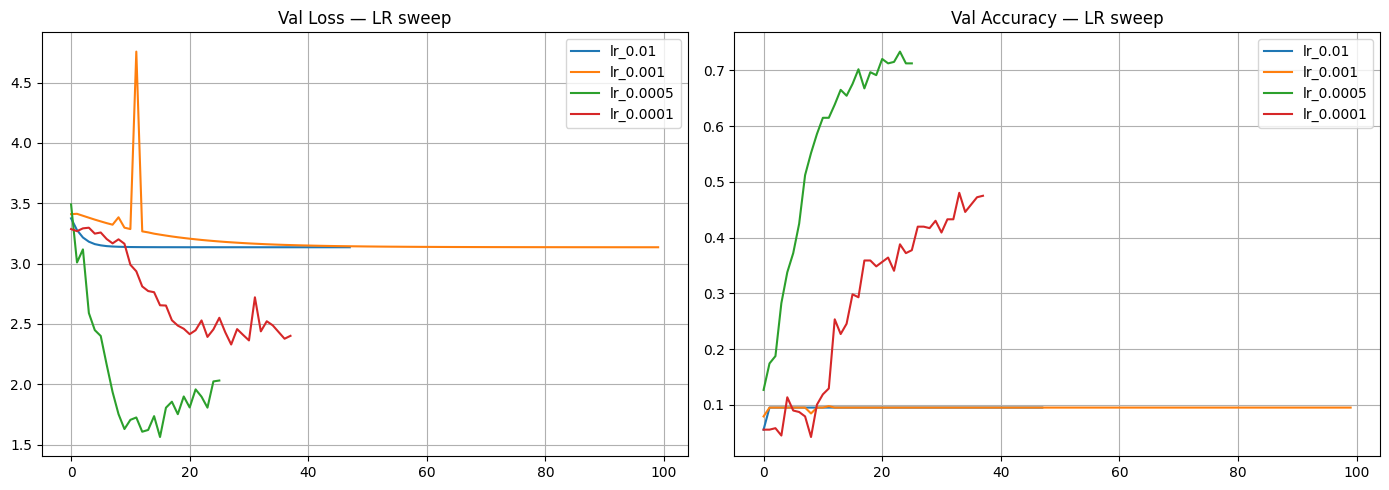

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1776584584.273597    4793 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_225678__.101


44/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0523 - loss: 27.3405

I0000 00:00:1776584588.265163    4792 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_225678__.101


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.0543 - loss: 26.1562

I0000 00:00:1776584591.058199    4793 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_227022__.28
I0000 00:00:1776584592.126749    4793 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_227022__.28


48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - accuracy: 0.0785 - loss: 12.9154 - val_accuracy: 0.1319 - val_loss: 3.1648 - learning_rate: 5.0000e-04
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1069 - loss: 3.2487 - val_accuracy: 0.1847 - val_loss: 3.0355 - learning_rate: 5.0000e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1544 - loss: 3.0259 - val_accuracy: 0.1847 - val_loss: 2.8541 - learning_rate: 5.0000e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1926 - loss: 2.8387 - val_accuracy: 0.2586 - val_loss: 2.6453 - learning_rate: 5.0000e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2856 - loss: 2.5221 - val_accuracy: 0.3325 - val_loss: 2.5097 - learning_rate: 5.0000e-04
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3496 - loss: 2.2558 - val_accuracy: 0.3747 - val_loss: 2.3432 - learning_rate: 5.0000e-04
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4070 - 

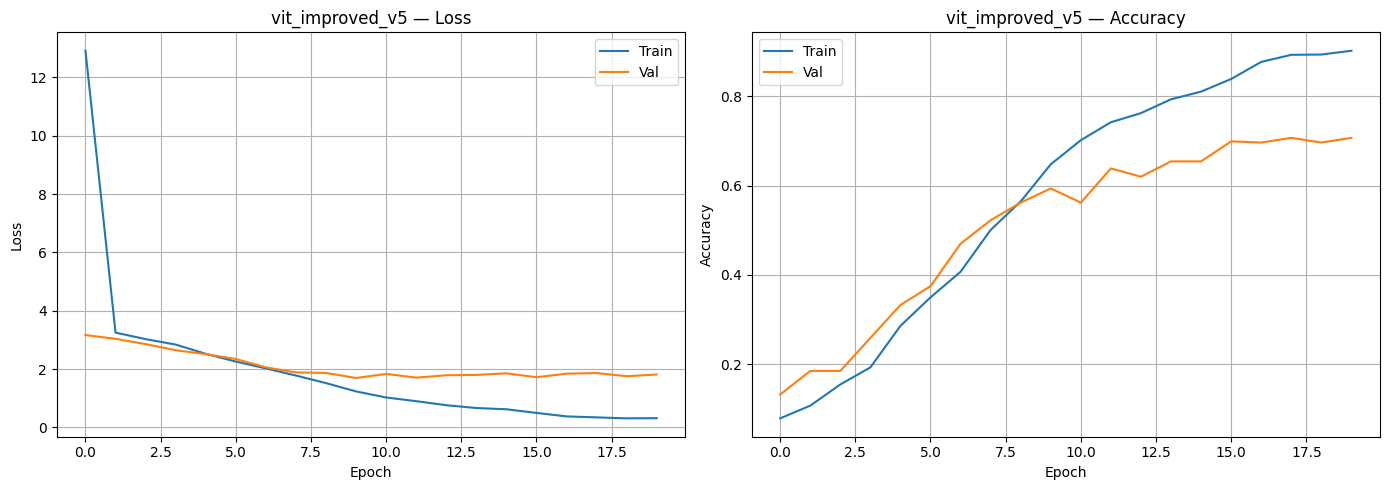

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}, wd={WEIGHT_DECAY}, dropout={DROPOUT_RATE}):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
print(f"  Gap train/val: {(train_acc - val_acc)*100:.1f} pts  (v3: 20.4, v4: 26.1)")

I0000 00:00:1776584612.302774    4791 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_227022__.28
I0000 00:00:1776584612.502959   23255 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776584612.839790   23262 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 80 bytes spill stores, 80 bytes spill loads



vit_improved_v5 (best LR=0.0005, wd=0.0001, dropout=0.1):
  Train — Loss: 0.8513, Acc: 0.7764
  Val   — Loss: 1.6913, Acc: 0.5937
  Gap train/val: 18.3 pts  (v3: 20.4, v4: 26.1)


I0000 00:00:1776584614.059662    4792 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_370798__.21
I0000 00:00:1776584615.082289    4793 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_371289__.21


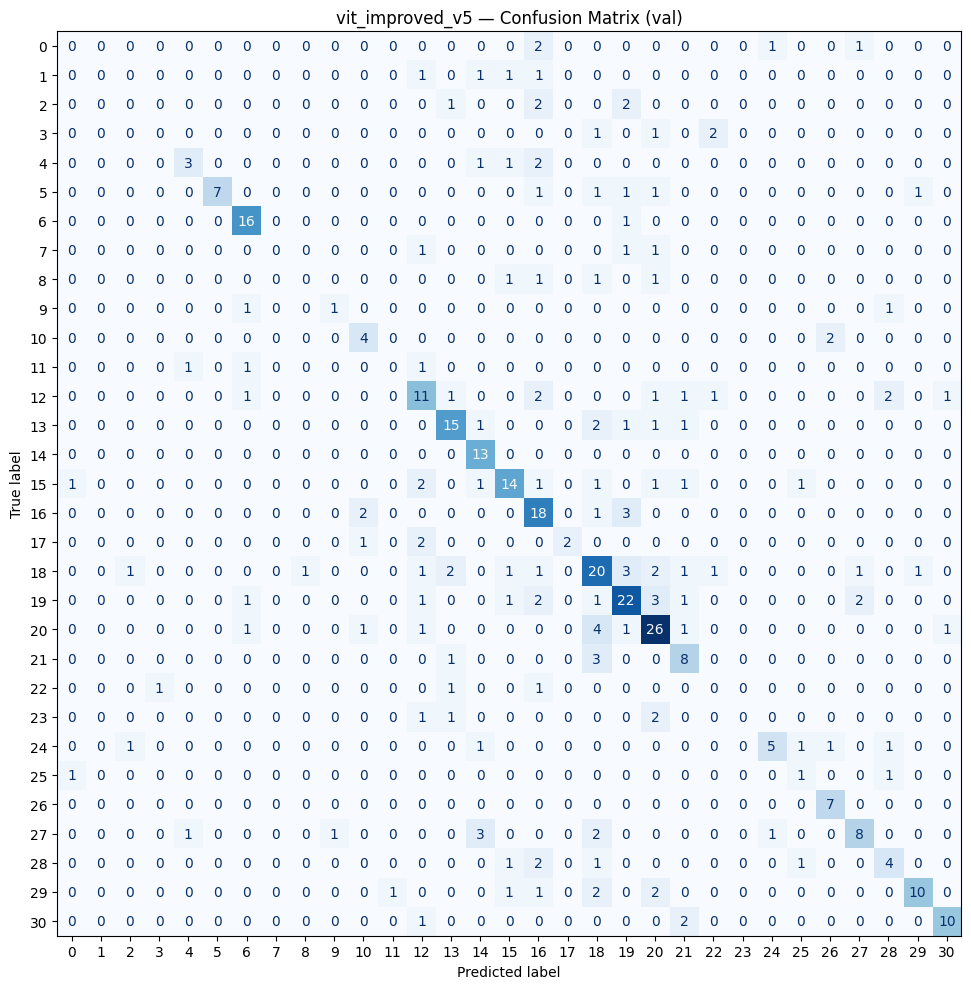

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

On garde le **fix retrain de v3** : `max(4*BEST_EPOCH, 60)` epochs.

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION, batch_size=BATCH_SIZE)

RETRAIN_EPOCHS = max(BEST_EPOCH * RETRAIN_EPOCHS_MULTIPLIER, RETRAIN_EPOCHS_MIN)
print(f"BEST_EPOCH du sweep : {BEST_EPOCH}")
print(f"RETRAIN_EPOCHS      : {RETRAIN_EPOCHS}  (= max({BEST_EPOCH}*{RETRAIN_EPOCHS_MULTIPLIER}, {RETRAIN_EPOCHS_MIN}))")
print(f"Retraining on full dataset ({len(X_all)} images) for {RETRAIN_EPOCHS} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_history = final_model.fit(
    all_ds, epochs=RETRAIN_EPOCHS,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
final_train_acc = final_model.evaluate(all_ds, verbose=0)[1]
print(f"\nFinal retrain train acc: {final_train_acc:.4f}")

BEST_EPOCH du sweep : 16
RETRAIN_EPOCHS      : 64  (= max(16*4, 60))
Retraining on full dataset (1895 images) for 64 epochs
Epoch 1/64


I0000 00:00:1776584620.145069    4791 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_381568__.101


53/60 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0796 - loss: 30.5756

I0000 00:00:1776584624.110172    4793 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_381568__.101
I0000 00:00:1776584624.324028   23523 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_148', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776584624.390776   23513 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_148', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1776584624.395396   23521 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_148', 8 bytes spill stores, 12 bytes spill loads

I0000 00:00:1776584624.483382   23511 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_148', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776584624.709193   23520 subprocess_comp

60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 218ms/step - accuracy: 0.0918 - loss: 13.3289
Epoch 2/64
 1/60 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.1562 - loss: 3.0268

I0000 00:00:1776584635.778207    4793 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_fusion', 96 bytes spill stores, 92 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_fusion_1', 88 bytes spill stores, 88 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_7', 40 bytes spill stores, 40 bytes spill loads



60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1562 - loss: 3.1154
Epoch 3/64
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1773 - loss: 2.9690
Epoch 4/64
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2781 - loss: 2.5761
Epoch 5/64
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3504 - loss: 2.2942
Epoch 6/64
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4554 - loss: 1.9587
Epoch 7/64
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5203 - loss: 1.7023
Epoch 8/64
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5942 - loss: 1.4377
Epoch 9/64
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6639 - loss: 1.1754
Epoch 10/64
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7219 - loss: 0.9372
Epoch 11/64
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7383 - loss: 0.8522
Epoch 12/64
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7889 - loss: 0.6995
Epoch 13/64
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8148 - loss: 0.5897

I0000 00:00:1776584667.771649    4792 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_431407__.28
I0000 00:00:1776584669.158113    4790 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_431407__.28
I0000 00:00:1776584669.291964   26394 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1776584669.678874   26395 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 84 bytes spill stores, 84 bytes spill loads




Final retrain train acc: 0.9599


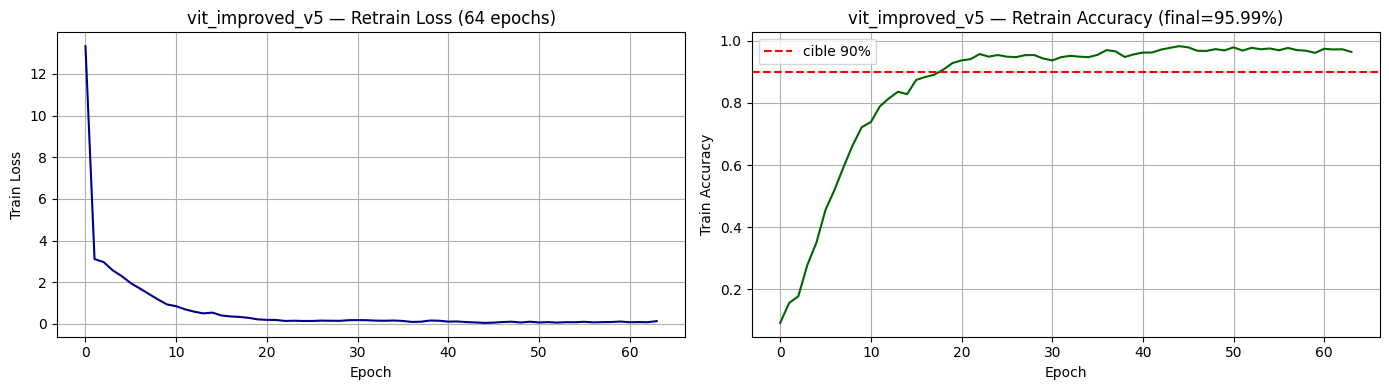

✅ Retrain converge : train acc = 95.99%


In [14]:
# Courbe de convergence du retrain — verifier que le modele a bien appris
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(final_history.history['loss'], color='darkblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title(f'{MODEL_NAME} — Retrain Loss ({RETRAIN_EPOCHS} epochs)'); axes[0].grid(True)

axes[1].plot(final_history.history['accuracy'], color='darkgreen')
axes[1].axhline(0.90, color='red', linestyle='--', label='cible 90%')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Train Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Retrain Accuracy (final={final_train_acc:.2%})')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_retrain.png'), dpi=150, bbox_inches='tight')
plt.show()

if final_train_acc < 0.90:
    print(f"⚠️  Retrain train acc = {final_train_acc:.2%} < 90%. Le dropout peut avoir regularise fortement -- c'est OK si la courbe monte regulierement. Verifier la courbe.")
else:
    print(f"✅ Retrain converge : train acc = {final_train_acc:.2%}")

In [15]:
# Extract embeddings from the layer before softmax
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.get_layer('embedding').output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

I0000 00:00:1776584671.437922    4790 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_432153__.19


 1/12 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step

I0000 00:00:1776584672.482380    4790 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_432620__.19
I0000 00:00:1776584672.687752   26516 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776584673.073310   26506 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776584673.215093   26513 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1776584673.754879   26514 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776584673.835560   26507 subprocess_compilation.cc:

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 380ms/step
Embedding shape: (371, 260)
Saved: /home/franck/kaggle_jaguar_classification/submissions/submission_vit_improved_v5.csv


,row_id,similarity
0,0,0.211253
1,1,0.247842
2,2,0.209921
3,3,0.443520
4,4,0.594977


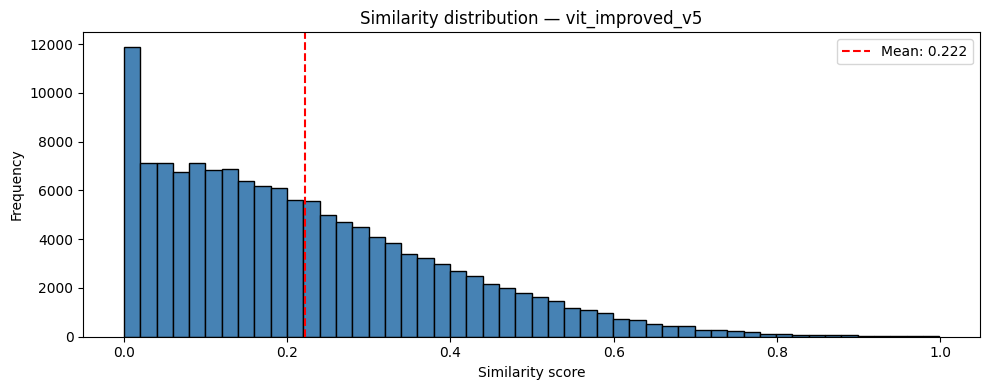

Similarity mean: 0.2217
Similarity std : 0.1726
Similarity min : 0.0000
Similarity max : 0.9988


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Similarity mean: {similarities.mean():.4f}")
print(f"Similarity std : {similarities.std():.4f}")
print(f"Similarity min : {similarities.min():.4f}")
print(f"Similarity max : {similarities.max():.4f}")

## 6. Observations & Verdict

In [17]:
print(f"""
ViT Improved v5 (AdamW + wd={WEIGHT_DECAY} + Dropout={DROPOUT_RATE}):
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  Gap train/val: {(train_acc - val_acc)*100:.1f} pts  (v3: 20.4, v4: 26.1)
  LR: {BEST_LR}, Weight decay: {WEIGHT_DECAY}, Dropout: {DROPOUT_RATE}
  Activation: {ACTIVATION}, Embed dim: {EMBED_DIM}, Blocks: {NUM_BLOCKS}
  Best Epoch: {BEST_EPOCH} / Retrain Epochs: {RETRAIN_EPOCHS}
  Retrain train acc: {final_train_acc:.2%}
  Embedding dim: {test_embeddings.shape[1]}
  Similarity mean: {similarities.mean():.4f}
  Similarity range: [{similarities.min():.4f}, {similarities.max():.4f}]
""")


ViT Improved v5 (AdamW + wd=0.0001 + Dropout=0.1):
  Train - Loss: 0.8513, Acc: 0.7764
  Val   - Loss: 1.6913, Acc: 0.5937
  Gap train/val: 18.3 pts  (v3: 20.4, v4: 26.1)
  LR: 0.0005, Weight decay: 0.0001, Dropout: 0.1
  Activation: relu, Embed dim: 64, Blocks: 3
  Best Epoch: 16 / Retrain Epochs: 64
  Retrain train acc: 95.99%
  Embedding dim: 260
  Similarity mean: 0.2217
  Similarity range: [0.0000, 0.9988]



### Results

| Metrique | v3 (Adam) | v4 (AdamW) | v5 (AdamW + Dropout 0.2) |
|----------|-----------|------------|---------------------------|
| Architecture | ViT + relu | ViT + relu (idem) | ViT + relu (idem) |
| BEST_LR | 1e-4 | 1e-4 | TODO |
| BEST_EPOCH (sweep) | 17 | 18 | TODO |
| Train accuracy (sweep) | 91.09 % | 98.42 % | TODO |
| Val accuracy (sweep) | 70.71 % | 72.30 % | TODO |
| Gap train/val | 20.4 pts | 26.1 pts | TODO |
| Retrain train acc | 100.00 % | 100.00 % | TODO |
| Similarity mean | 0.7117 | 0.8086 | TODO |
| Similarity range | [0.063, 0.998] | [0.398, 0.999] | TODO |
| Kaggle public | 0.238 | 0.264 | TODO |
| Kaggle private | 0.233 | 0.271 | TODO |

### Analysis

- TODO : Le gap train/val a-t-il diminue vs v4 (26 pts) ? -> indicateur direct de l'effet du dropout
- TODO : BEST_LR a-t-il change ? Avec dropout, le LR optimal peut etre un peu plus grand (la regularisation absorbe le bruit)
- TODO : Retrain train acc < 100 % ? Si oui, le dropout regularise meme sans val (c'est OK si > 90 %)
- TODO : Distribution des similarites : plus bimodale qu'en v4 ? Dropout peut mieux separer les classes dans l'espace cosinus
- TODO : Kaggle vs v4 (0.264 / 0.271) : en hausse (regularisation effective) ? stagnation (dropout trop faible) ? baisse (dropout trop fort) ?

### Verdict

- [ ] Improvable -> Instructions for v6 (data augmentation, ou augmenter dropout, ou label smoothing)
- [ ] Not Improvable -> Ceiling reached, why ?
- [ ] Dead-end -> We ff cette technique, why ?

### Interpretation

_Free Space : On note ce qu'on a a dire sur ce notebook, servira pour la soutenance._

Points cles a mentionner :
- **Dropout (0.2) est le regularisateur canonique du cours** : il attaque l'overfitting structurel en forcant la redondance. Complementaire a AdamW qui regularise la norme.
- **Placement strategique** : 3 points (apres attention, apres FFN, apres embedding). Le choix reflete l'architecture naïve du cours, sans toucher au dropout d'attention avance.
- **Valeur 0.2 conservatrice** : on verifie d'abord si l'effet est positif avant d'aller plus haut (0.3, 0.4) en v6.
- **Comparaison ResNet** : le ResNet-34 a beneficie fortement du dropout (06_5 -> 06_7 : +0.08 Kaggle). Meme logique attendue pour le ViT.
- **Si gap ne bouge pas** : passer a data augmentation en v6 (noisy inputs du cours), puis label smoothing si besoin.